# Data setup and EDA

2,240 customers from a marketing campaign dataset - demographics, how
much they spend across product categories, how they shop (web/catalog/
store), and whether they responded to the most recent marketing
campaign. Two questions drive the rest of this project: can campaign
response be predicted (supervised), and do customers naturally segment
by spending/engagement pattern (unsupervised)?

In [1]:
import os
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = 'data'
DATA_PATH = os.path.join(DATA_DIR, 'marketing_campaign.csv')
DATA_URL = 'https://raw.githubusercontent.com/Abdulraqib20/Customer-Personality-Analysis/main/marketing_campaign.csv'

os.makedirs(DATA_DIR, exist_ok = True)
if not os.path.exists(DATA_PATH):
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)

customers = pd.read_csv(DATA_PATH, sep = '\t')
customers.shape

(2240, 29)

In [2]:
customers.isna().sum()[customers.isna().sum() > 0]

Income    24
dtype: int64

Only `Income` has missing values (24 of 2,240, ~1%) - dropped rather than imputed, since it's such a small fraction. `Marital_Status` has a couple of joke/placeholder entries (`Absurd`, `YOLO`) that need cleaning before any grouping by marital status.

In [3]:
customers['Marital_Status'].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [4]:
customers = customers.dropna(subset = ['Income']).copy()
customers['Marital_Status'] = customers['Marital_Status'].replace(
    {'Absurd': 'Single', 'YOLO': 'Single', 'Alone': 'Single'})
customers['Dt_Customer'] = pd.to_datetime(customers['Dt_Customer'], format = '%d-%m-%Y')
customers['Age'] = 2014 - customers['Year_Birth']

customers['Response'].value_counts(normalize = True)

Response
0    0.849729
1    0.150271
Name: proportion, dtype: float64

Only 14.9% of customers responded to the most recent campaign - a real imbalance, handled properly in the modeling notebook rather than assuming plain accuracy tells the whole story.

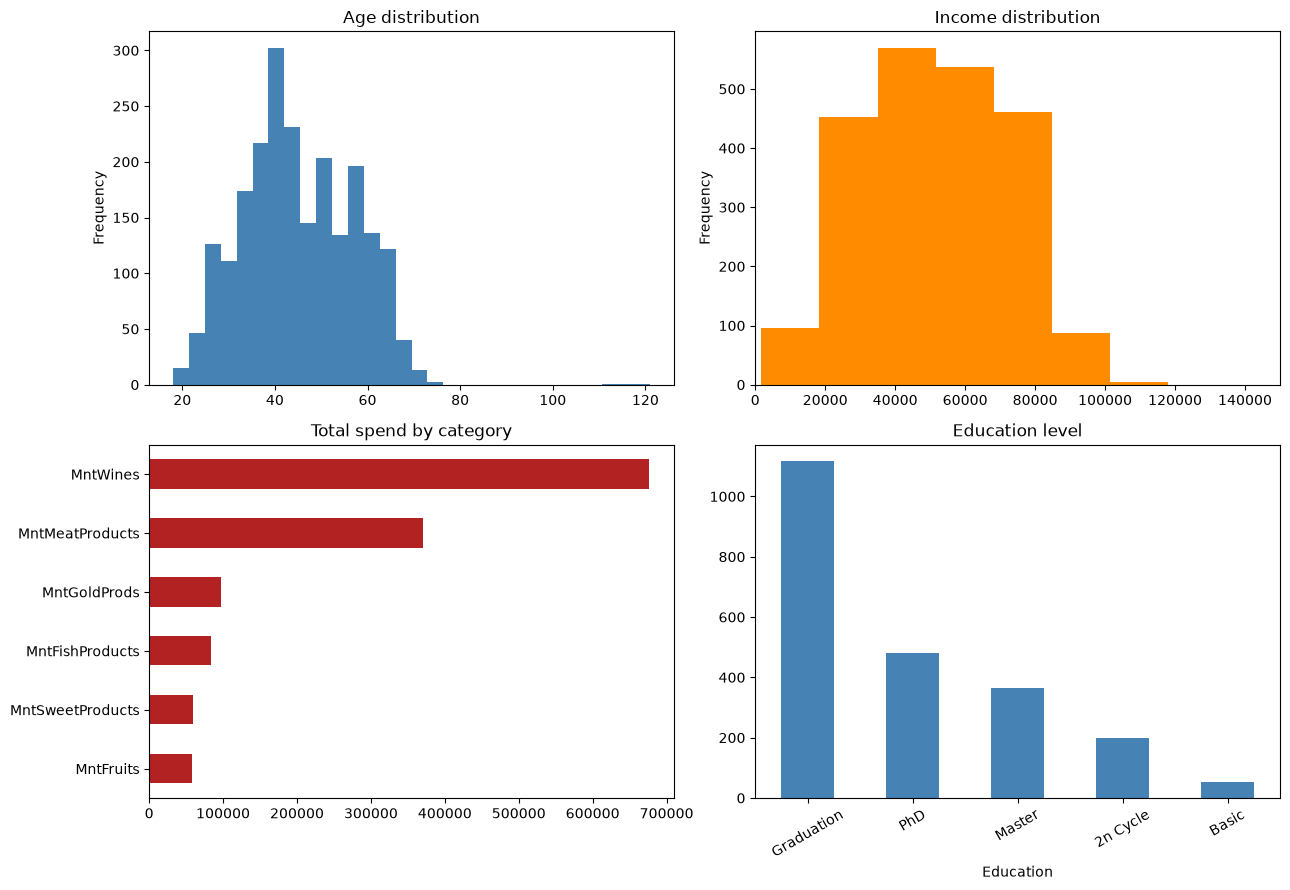

In [5]:
spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
customers['TotalSpend'] = customers[spend_cols].sum(axis = 1)

fig, axes = plt.subplots(2, 2, figsize = (13, 9))

customers['Age'].plot.hist(bins = 30, ax = axes[0, 0], color = 'steelblue')
axes[0, 0].set_title('Age distribution')

customers['Income'].plot.hist(bins = 40, ax = axes[0, 1], color = 'darkorange')
axes[0, 1].set_xlim(0, 150000)
axes[0, 1].set_title('Income distribution')

customers[spend_cols].sum().sort_values().plot.barh(ax = axes[1, 0], color = 'firebrick')
axes[1, 0].set_title('Total spend by category')

customers['Education'].value_counts().plot.bar(ax = axes[1, 1], color = 'steelblue')
axes[1, 1].set_title('Education level')
axes[1, 1].tick_params(axis = 'x', rotation = 30)

plt.tight_layout()
plt.savefig('outputs/eda_overview.png', dpi = 120)
plt.show()

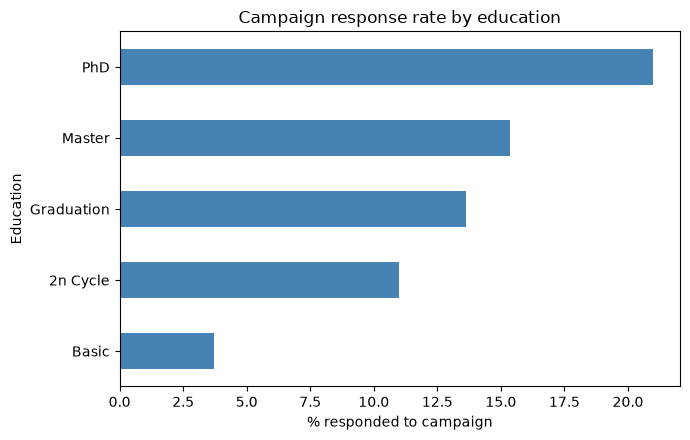

In [6]:
response_by_education = customers.groupby('Education')['Response'].mean() * 100

fig, ax = plt.subplots(figsize = (7, 4.5))
response_by_education.sort_values().plot.barh(ax = ax, color = 'steelblue')
ax.set_xlabel('% responded to campaign')
ax.set_title('Campaign response rate by education')
plt.tight_layout()
plt.savefig('outputs/response_by_education.png', dpi = 120)
plt.show()

In [7]:
import json

os.makedirs('outputs', exist_ok = True)
summary = {
    'n_customers': int(len(customers)),
    'response_rate': float(customers['Response'].mean()),
    'complain_rate': float(customers['Complain'].mean()),
    'mean_income': float(customers['Income'].mean()),
    'mean_total_spend': float(customers['TotalSpend'].mean()),
}
with open('outputs/data_summary.json', 'w') as f:
    json.dump(summary, f, indent = 2)

customers.to_csv('outputs/customers_clean.csv', index = False)
summary

{'n_customers': 2216,
 'response_rate': 0.15027075812274368,
 'complain_rate': 0.00947653429602888,
 'mean_income': 52247.25135379061,
 'mean_total_spend': 607.0753610108303}